# DS605 Lab 4: Airbnb Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48895
Number of columns: 16


In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
reviews_per_month,10052,20.558339
last_review,10052,20.558339
host_name,21,0.042949
name,16,0.032723


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64
Minimum price: 0
Maximum price: 10000
Mean price: 152.7206871868289
Median price: 106.0


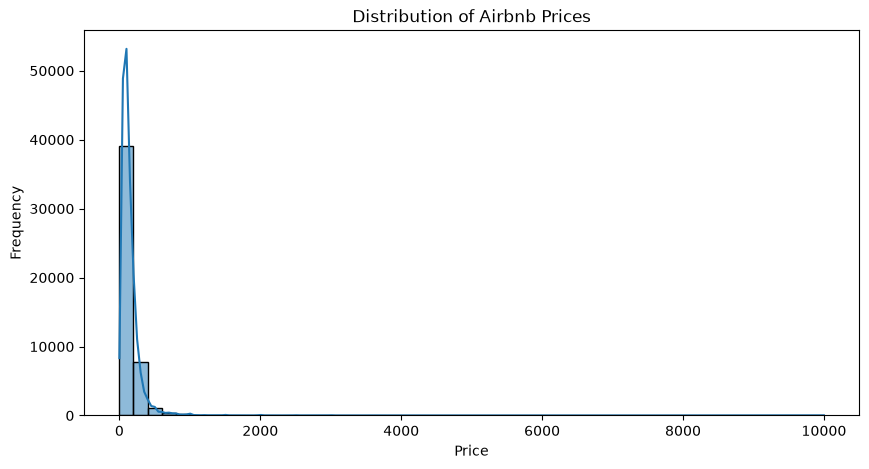

In [10]:
print(df["price"].describe())

print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())
print("Mean price:", df["price"].mean())
print("Median price:", df["price"].median())

plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [11]:
# Check zero-price listings
zero_price_count = (df["price"] == 0).sum()

print("Number of listings with price = 0:", zero_price_count)
print("Percentage of listings with price = 0:",
      round((zero_price_count / len(df)) * 100, 2), "%")


# Price percentiles
print("\nPrice Percentiles:")
print(df["price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]))


# Common high-price thresholds
print("\nListings above selected price thresholds:")

for threshold in [300, 500, 1000, 2000, 5000]:
    count = (df["price"] > threshold).sum()
    percentage = (count / len(df)) * 100
    
    print(f"Price > ${threshold}: {count} listings ({percentage:.2f}%)")


# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Number of listings with price = 0: 11
Percentage of listings with price = 0: 0.02 %

Price Percentiles:
0.500      106.0
0.750      175.0
0.900      269.0
0.950      355.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64

Listings above selected price thresholds:
Price > $300: 3357 listings (6.87%)
Price > $500: 1044 listings (2.14%)
Price > $1000: 239 listings (0.49%)
Price > $2000: 86 listings (0.18%)
Price > $5000: 20 listings (0.04%)

Duplicate rows: 0


In [12]:
# Show the most expensive listings
df.sort_values("price", ascending=False)[
    [
        "name",
        "neighbourhood_group",
        "neighbourhood",
        "room_type",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "availability_365"
    ]
].head(20)

,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365
29238,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000,30,0,83
9151,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000,100,2,0
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000,5,5,0
6530,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999,5,1,0
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999,30,0,365
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999,99,6,83
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500,30,2,251
4377,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000,1,1,365
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703,1,0,146
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500,1,0,364


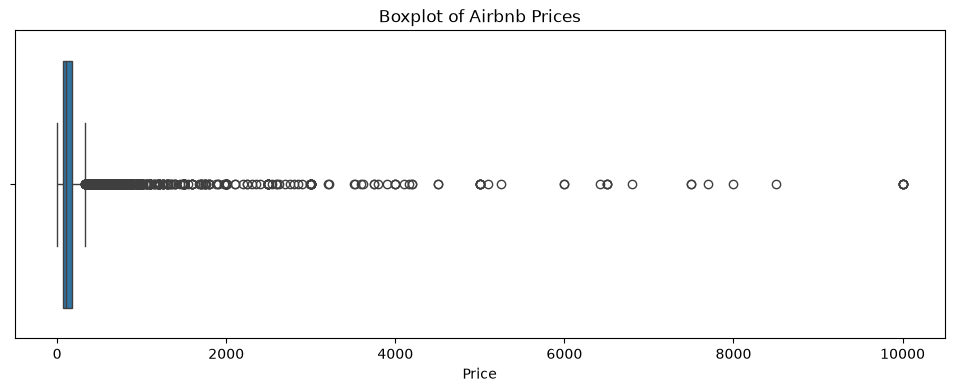

In [13]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price")

plt.show()

In [14]:
# Remove listings with zero price

print("Rows before removing zero prices:", len(df))

df = df[df["price"] > 0].copy()

print("Rows after removing zero prices:", len(df))
print("Zero-price listings remaining:", (df["price"] == 0).sum())

Rows before removing zero prices: 48895
Rows after removing zero prices: 48884
Zero-price listings remaining: 0


In [15]:
# Investigate why reviews_per_month is missing

missing_reviews = df[df["reviews_per_month"].isna()]

print("Listings with missing reviews_per_month:",
      len(missing_reviews))

print("\nNumber of reviews for these listings:")
print(missing_reviews["number_of_reviews"].describe())

print("\nListings with missing reviews_per_month and zero reviews:",
      (missing_reviews["number_of_reviews"] == 0).sum())

print("\nListings with missing reviews_per_month but having reviews:",
      (missing_reviews["number_of_reviews"] > 0).sum())

Listings with missing reviews_per_month: 10051

Number of reviews for these listings:
count    10051.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: number_of_reviews, dtype: float64

Listings with missing reviews_per_month and zero reviews: 10051

Listings with missing reviews_per_month but having reviews: 0


In [16]:
# Missing reviews_per_month means the listing has no reviews
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(
    "Missing reviews_per_month:",
    df["reviews_per_month"].isna().sum()
)

Missing reviews_per_month: 0


In [17]:
# Drop last_review because missing values represent listings
# that have never received a review.

df = df.drop(columns=["last_review"])

print("last_review" in df.columns)

False


In [18]:
print("Current dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Current dataset shape: (48884, 15)

Missing values:
id                                 0
name                              16
host_id                            0
host_name                         21
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64


In [19]:
# Check unique values in categorical columns

categorical_columns = df.select_dtypes(
    include=["object", "str"]
).columns

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

name: 47894 unique values
host_name: 11450 unique values
neighbourhood_group: 5 unique values
neighbourhood: 221 unique values
room_type: 3 unique values


In [20]:
# Check the most common values

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- name ---
name
Hillside Hotel                                18
Home away from home                           17
New york Multi-unit building                  16
Brooklyn Apartment                            12
Loft Suite @ The Box House Hotel              11
Private Room                                  11
Private room                                  10
Artsy Private BR in Fort Greene Cumberland    10
Beautiful Brooklyn Brownstone                  8
Private room in Brooklyn                       8
Name: count, dtype: int64

--- host_name ---
host_name
Michael         417
David           403
Sonder (NYC)    327
John            294
Alex            279
Blueground      232
Sarah           227
Daniel          226
Jessica         205
Maria           204
Name: count, dtype: int64

--- neighbourhood_group ---
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

--- neighbourhood -

In [21]:
# Numerical feature summary

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(df[numerical_columns].describe().T)


# Number of unique values in numerical columns

for col in numerical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

                                  count          mean           std  \
id                              48884.0  1.901679e+07  1.098432e+07   
host_id                         48884.0  6.762203e+07  7.861666e+07   
latitude                        48884.0  4.072895e+01  5.453177e-02   
longitude                       48884.0 -7.395218e+01  4.615874e-02   
price                           48884.0  1.527551e+02  2.401703e+02   
minimum_nights                  48884.0  7.029887e+00  2.051222e+01   
number_of_reviews               48884.0  2.327199e+01  4.455133e+01   
reviews_per_month               48884.0  1.090800e+00  1.597213e+00   
calculated_host_listings_count  48884.0  7.144628e+00  3.295619e+01   
availability_365                48884.0  1.127795e+02  1.316273e+02   

                                       min           25%           50%  \
id                              2539.00000  9.470548e+06  1.967574e+07   
host_id                         2438.00000  7.817310e+06  3.079257e+07

In [22]:
# Investigate minimum_nights

print("Minimum nights percentiles:")
print(
    df["minimum_nights"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
    )
)

print("\nListings above selected thresholds:")

for threshold in [7, 14, 30, 60, 90, 180, 365]:
    count = (df["minimum_nights"] > threshold).sum()
    percentage = (count / len(df)) * 100
    
    print(
        f"Minimum nights > {threshold}: "
        f"{count} listings ({percentage:.2f}%)"
    )

Minimum nights percentiles:
0.500       3.0
0.750       5.0
0.900      28.0
0.950      30.0
0.990      45.0
0.995      90.0
1.000    1250.0
Name: minimum_nights, dtype: float64

Listings above selected thresholds:
Minimum nights > 7: 7331 listings (15.00%)
Minimum nights > 14: 5898 listings (12.07%)
Minimum nights > 30: 747 listings (1.53%)
Minimum nights > 60: 332 listings (0.68%)
Minimum nights > 90: 197 listings (0.40%)
Minimum nights > 180: 81 listings (0.17%)
Minimum nights > 365: 14 listings (0.03%)


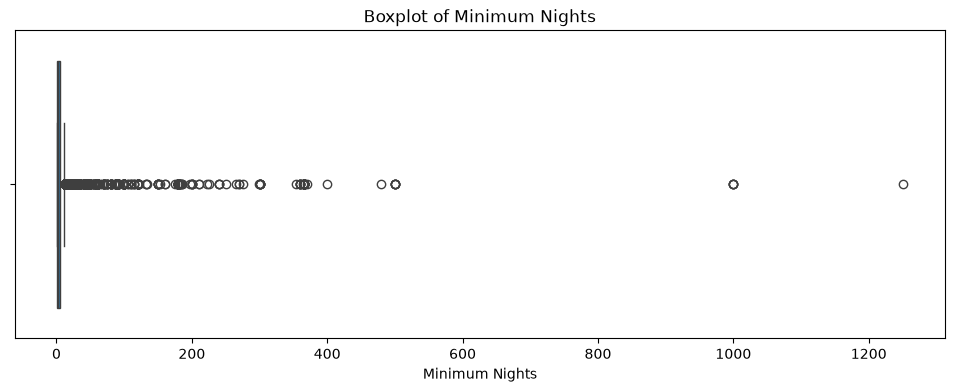

In [23]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=df["minimum_nights"])

plt.title("Boxplot of Minimum Nights")
plt.xlabel("Minimum Nights")

plt.show()

In [24]:
# Inspect extremely high minimum-night listings

extreme_min_nights = df[df["minimum_nights"] > 365][
    [
        "name",
        "neighbourhood_group",
        "neighbourhood",
        "room_type",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "availability_365"
    ]
].sort_values("minimum_nights", ascending=False)

print(extreme_min_nights)

                                      name neighbourhood_group  \
5767      Prime W. Village location 1 bdrm           Manhattan   
2854                                   NaN           Manhattan   
26341      Beautiful place in Brooklyn! #2            Brooklyn   
38664         Shared Studio (females only)           Manhattan   
13404   Historic Designer 2 Bed. Apartment           Manhattan   
8014             Wonderful Large 1 bedroom           Manhattan   
47620               Williamsburg Apartment            Brooklyn   
14285      Peaceful apartment close to F/G            Brooklyn   
7355   Beautiful Fully Furnished 1 bed/bth              Queens   
11193   Zen Room in Crown Heights Brooklyn            Brooklyn   
10829  Brand New Luxury Apt Lease Takeover              Queens   
34487                        Not available            Brooklyn   
1305   800sqft apartment with huge terrace            Brooklyn   
15946   Bright Luxury Studio, Central Loc.           Manhattan   

         

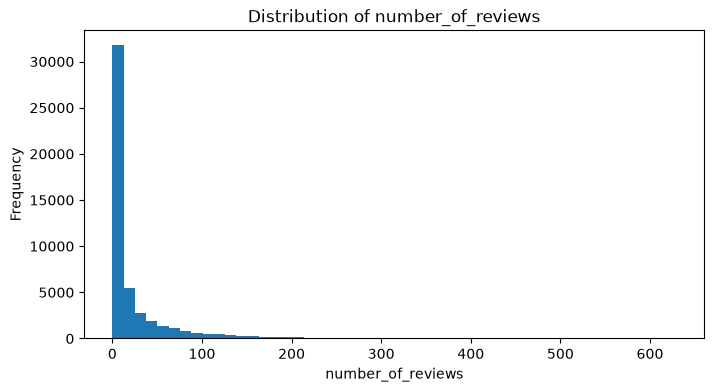

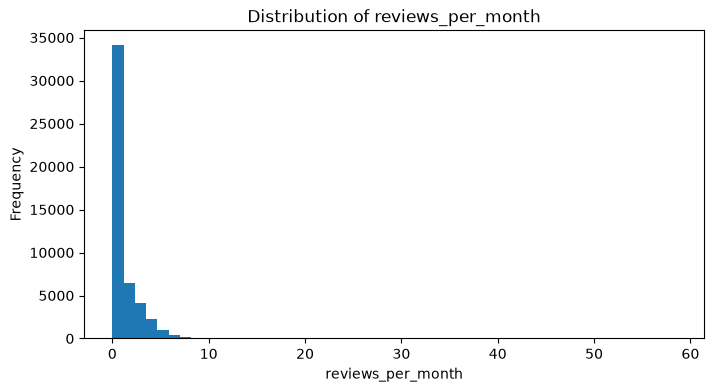

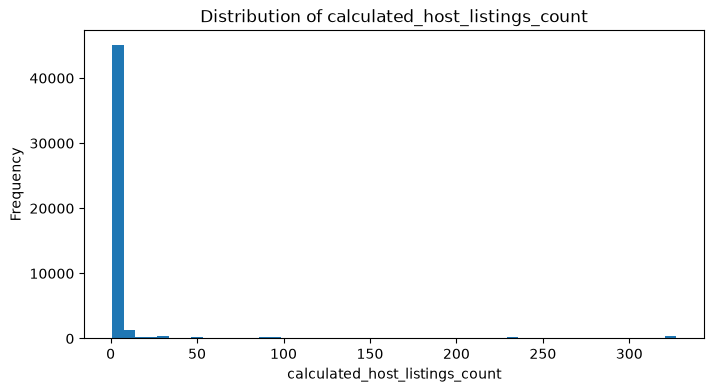

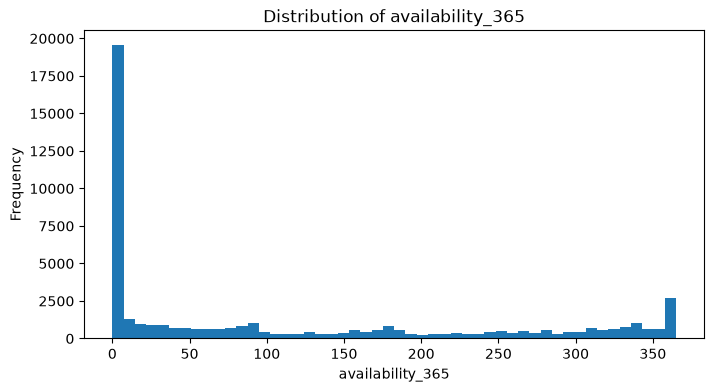

In [25]:
# Plot distributions of important numerical features

features_to_check = [
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for col in features_to_check:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [26]:
# Check skewness

for col in features_to_check:
    print(f"{col}: skewness = {df[col].skew():.2f}")

number_of_reviews: skewness = 3.69
reviews_per_month: skewness = 3.30
calculated_host_listings_count: skewness = 7.93
availability_365: skewness = 0.76


In [27]:
# Handle extreme minimum_nights values using 99th percentile capping

upper_limit = df["minimum_nights"].quantile(0.99)

print("99th percentile:", upper_limit)

df["minimum_nights"] = df["minimum_nights"].clip(
    upper=upper_limit
)

print("Maximum minimum_nights after capping:",
      df["minimum_nights"].max())

99th percentile: 45.0
Maximum minimum_nights after capping: 45


In [28]:
# Log transformation for minimum_nights

df["minimum_nights_log"] = np.log1p(
    df["minimum_nights"]
)

print(df[[
    "minimum_nights",
    "minimum_nights_log"
]].head())

   minimum_nights  minimum_nights_log
0               1            0.693147
1               1            0.693147
2               3            1.386294
3               1            0.693147
4              10            2.397895


In [29]:
# Remove identifier and high-cardinality text columns

df = df.drop(
    columns=["id", "host_id", "name", "host_name"]
)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'minimum_nights_log']


In [30]:
# Final data cleaning check

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (48884, 12)

Missing values:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
minimum_nights_log                0
dtype: int64

Duplicate rows: 0


In [31]:
# Log transformation for right-skewed numerical features

log_features = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for col in log_features:
    df[col + "_log"] = np.log1p(df[col])

print("Log-transformed features created:")
print([col + "_log" for col in log_features])

Log-transformed features created:
['minimum_nights_log', 'number_of_reviews_log', 'reviews_per_month_log', 'calculated_host_listings_count_log']


In [32]:
# Log-transform the target variable

df["price_log"] = np.log1p(df["price"])

print("Original price:")
print(df["price"].describe())

print("\nLog-transformed price:")
print(df["price_log"].describe())

Original price:
count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Log-transformed price:
count    48884.000000
mean         4.737951
std          0.691782
min          2.397895
25%          4.248495
50%          4.672829
75%          5.170484
max          9.210440
Name: price_log, dtype: float64


In [33]:
# Correlation with log-transformed price

correlation = df.select_dtypes(
    include=["int64", "float64"]
).corr()["price_log"].sort_values(ascending=False)

print(correlation)

price_log                             1.000000
price                                 0.640074
calculated_host_listings_count        0.132836
availability_365                      0.099179
latitude                              0.079285
minimum_nights_log                    0.064070
calculated_host_listings_count_log    0.050518
minimum_nights                        0.048400
number_of_reviews                    -0.042650
reviews_per_month                    -0.060483
reviews_per_month_log                -0.060880
number_of_reviews_log                -0.065949
longitude                            -0.325892
Name: price_log, dtype: float64


In [34]:
# Final candidate features and target

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights_log",
    "number_of_reviews_log",
    "reviews_per_month_log",
    "calculated_host_listings_count_log",
    "availability_365"
]

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

target = "price_log"

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTarget:", target)

Numerical features:
['latitude', 'longitude', 'minimum_nights_log', 'number_of_reviews_log', 'reviews_per_month_log', 'calculated_host_listings_count_log', 'availability_365']

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Target: price_log


## TASK 2 — MODEL TRAINING & EVALUATION

In [35]:
# Task 2 - Model Training and Evaluation

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import numpy as np
import pandas as pd

In [36]:
# Features and target

X = df[numerical_features + categorical_features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48884, 10)
y shape: (48884,)


In [37]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39107, 10)
Testing data: (9777, 10)


In [38]:
# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [39]:
# Linear Regression

linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [40]:
# Evaluate Linear Regression

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("-----------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
-----------------
MAE : 0.3374849387338532
RMSE: 0.4694871907192745
R²  : 0.5410190092946482


In [41]:
# Ridge Regression

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_pipeline.fit(X_train, y_train)

y_pred_ridge = ridge_pipeline.predict(X_test)

print("Ridge Regression trained successfully.")

Ridge Regression trained successfully.


In [42]:
# Evaluate Ridge Regression

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)

r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("----------------")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

Ridge Regression
----------------
MAE : 0.3374574145509992
RMSE: 0.4692231141320351
R²  : 0.541535198226269


In [43]:
# Random Forest Regression

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [44]:
# Evaluate Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
-------------
MAE : 0.31470150062811236
RMSE: 0.4475524458855172
R²  : 0.582904913741368


In [45]:
# Gradient Boosting Regression

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [46]:
# Evaluate Gradient Boosting

mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("-----------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting
-----------------
MAE : 0.32428135303478656
RMSE: 0.4536109007093043
R²  : 0.5715361668750867


In [47]:
# Compare regression models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_ridge,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_rf,
        rmse_gb
    ],
    "R2": [
        r2_linear,
        r2_ridge,
        r2_rf,
        r2_gb
    ]
})

results = results.sort_values(
    by="RMSE",
    ascending=True
)

print(results)

               Model       MAE      RMSE        R2
2      Random Forest  0.314702  0.447552  0.582905
3  Gradient Boosting  0.324281  0.453611  0.571536
1   Ridge Regression  0.337457  0.469223  0.541535
0  Linear Regression  0.337485  0.469487  0.541019


## TASK 2 — PART 2: Hyperparameter Tuning

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [49]:
# Hyperparameter search space for Random Forest

param_distributions = {
    "model__n_estimators": randint(100, 301),
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", 1.0]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [50]:
# Randomized hyperparameter tuning

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Best Parameters:
{'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 7, 'model__n_estimators': 188}

Best CV RMSE:
0.43469096505111327


In [51]:
# Best tuned Random Forest pipeline

best_rf = random_search.best_estimator_

print(best_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'minimum_nights_log',
                                                   'number_of_reviews_log',
                                                   'reviews_per_month_log',
                                                   'calculated_host_listings_count_log',
                                                   'availability_365']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighbourhood_group',
                                                   'neighbourhood',
                                                   'room_type'])])),
                ('model',
                 RandomForestRegressor(max_de

In [52]:
# Predictions from tuned Random Forest

y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned)
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

print("Tuned Random Forest")
print("-------------------")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest
-------------------
MAE : 0.3103704697135646
RMSE: 0.44019847869219964
R²  : 0.5964993131372793


In [53]:
# Check for overfitting

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print("Training R² :", train_r2)
print("Testing R²  :", test_r2)

print("\nTraining RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

Training R² : 0.7938495654115959
Testing R²  : 0.5964993131372793

Training RMSE: 0.3139534982746474
Testing RMSE : 0.44019847869219964


In [54]:
# Convert predictions and actual values back to original price scale

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_tuned)

final_mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

final_rmse = np.sqrt(
    mean_squared_error(y_test_actual, y_pred_actual)
)

final_r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

print("Final Random Forest Performance")
print("--------------------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Random Forest Performance
--------------------------------
MAE : 55.28299275831559
RMSE: 180.1658856480645
R²  : 0.18923499925615817


In [55]:
# Compare all regression models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_ridge,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_rf,
        rmse_gb
    ],
    "R2": [
        r2_linear,
        r2_ridge,
        r2_rf,
        r2_gb
    ]
})

results = results.sort_values("RMSE").reset_index(drop=True)

print("Model Comparison:")
print(results)

Model Comparison:
               Model       MAE      RMSE        R2
0      Random Forest  0.314702  0.447552  0.582905
1  Gradient Boosting  0.324281  0.453611  0.571536
2   Ridge Regression  0.337457  0.469223  0.541535
3  Linear Regression  0.337485  0.469487  0.541019


In [56]:
# Feature importance from Random Forest

rf_model = best_rf.named_steps["model"]

# Get transformed feature names
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                                     Feature  Importance
230           cat__room_type_Entire home/apt    0.207771
231              cat__room_type_Private room    0.168144
1                             num__longitude    0.124179
0                              num__latitude    0.095395
6                      num__availability_365    0.060426
2                    num__minimum_nights_log    0.040225
4                 num__reviews_per_month_log    0.038830
5    num__calculated_host_listings_count_log    0.036903
9         cat__neighbourhood_group_Manhattan    0.036032
3                 num__number_of_reviews_log    0.032992
232               cat__room_type_Shared room    0.021990
10           cat__neighbourhood_group_Queens    0.014280
138               cat__neighbourhood_Midtown    0.013098
8          cat__neighbourhood_group_Brooklyn    0.011629
39               cat__neighbourhood_Bushwick    0.005630


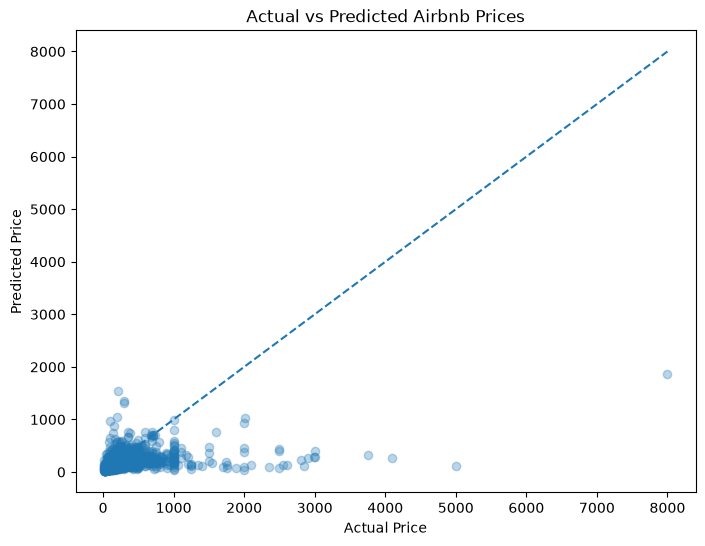

In [57]:
# Actual vs Predicted Price

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_rf)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")

# Perfect prediction line
min_value = min(y_test_actual.min(), y_pred_actual.min())
max_value = max(y_test_actual.max(), y_pred_actual.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

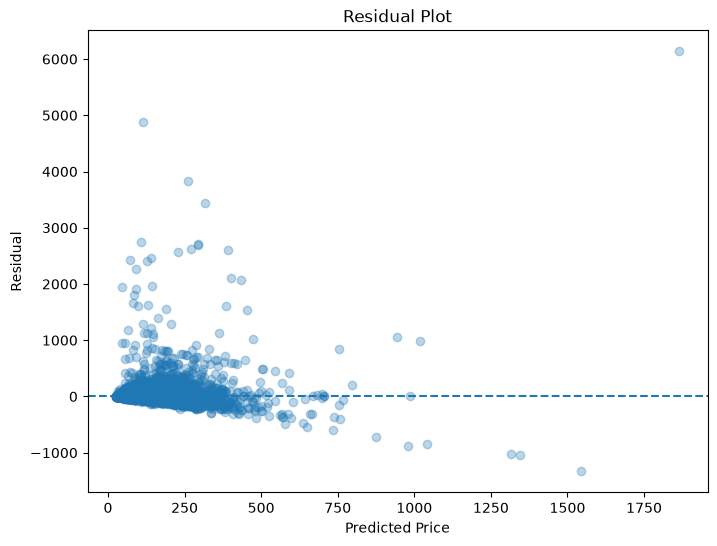

In [58]:
# Residual Analysis

residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_actual,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [59]:
# Final tuned Random Forest evaluation on original price scale

y_test_actual = np.expm1(y_test)
y_pred_tuned_actual = np.expm1(y_pred_tuned)

final_mae = mean_absolute_error(
    y_test_actual,
    y_pred_tuned_actual
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_tuned_actual
    )
)

final_r2 = r2_score(
    y_test_actual,
    y_pred_tuned_actual
)

print("Final Tuned Random Forest Performance")
print("-------------------------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Tuned Random Forest Performance
-------------------------------------
MAE : 55.28299275831559
RMSE: 180.1658856480645
R²  : 0.18923499925615817


In [60]:
# Save final tuned Random Forest pipeline

import joblib

joblib.dump(
    best_rf,
    "airbnb_price_model.pkl"
)

print("Final model pipeline saved successfully.")

Final model pipeline saved successfully.


In [61]:
# Final model comparison results

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_ridge,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_rf,
        rmse_gb
    ],
    "R2": [
        r2_linear,
        r2_ridge,
        r2_rf,
        r2_gb
    ]
})

print(comparison.round(4).to_string(index=False))

            Model    MAE   RMSE     R2
Linear Regression 0.3375 0.4695 0.5410
 Ridge Regression 0.3375 0.4692 0.5415
    Random Forest 0.3147 0.4476 0.5829
Gradient Boosting 0.3243 0.4536 0.5715


# Task 4 - Final Project Summary

### 1. Problem Statement

The objective of this project is to develop a machine learning regression model to predict the nightly price of Airbnb listings using listing characteristics such as location, room type, minimum nights, reviews, host information, and availability.

### 2. Data Preprocessing

The dataset was examined for missing values, duplicate records, invalid prices, and unusual values.

Duplicate rows were checked and none were found.
Listings with zero price were removed.
reviews_per_month was handled by replacing missing values with 0 because missing values corresponded to listings with zero reviews.
last_review was removed because it was not used as a modelling feature.
Missing categorical values in name and host_name were handled during preprocessing.
Numerical features were scaled using StandardScaler.
Categorical features were encoded using OneHotEncoder with handle_unknown="ignore".


### 3. Feature Engineering

The following numerical variables were log-transformed to reduce the influence of highly skewed values:

minimum_nights
number_of_reviews
reviews_per_month
calculated_host_listings_count

The target price was also modelled using a log transformation.

### 4. Models Used

Four regression models were evaluated:

Linear Regression
Ridge Regression
Random Forest Regressor
Gradient Boosting Regressor

Random Forest gave the strongest initial performance.

### 5. Hyperparameter Tuning

Randomized Search was used to tune the Random Forest hyperparameters.

The tuned model was then evaluated on the test set.

### 6. Final Model

The final selected model was the tuned Random Forest Regressor, integrated with the preprocessing pipeline.

### 7. Final Performance
MAE  = $55.28  
RMSE = $180.17  
R²   = 0.1892  

The MAE means that, on average, the model's prediction differs from the actual nightly price by approximately $55.28 on the original price scale.

### 8. Streamlit Application

A Streamlit application was created to provide an interactive interface where users can enter Airbnb listing information and receive an estimated nightly price.

Three realistic test cases were evaluated:

Test	Location	Room Type	Prediction  
#### 1	Manhattan / Midtown	Entire home/apt	$279.90  
#### 2	Brooklyn / Williamsburg	Private room	$81.61  
#### 3	Queens / Long Island City	Private room	$76.11  

This demonstrates that the trained model can be integrated into an interactive prediction application.